
# 1. Project Title 
## EDA (Exploratory Data Analysis)

# Smart Pricing Analysis for Global Markets
###  Data Analytics Project
Name: Priya Sarathe

Course Name: Data Analytics (DA/DS 49)

## Objective
The objective of this project is to analyze global pricing patterns, sales trends, and revenue generation across different countries and products using Python, SQL, Excel, statistics, and Power BI.
```

In [2]:
pip install IPython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\hp\AppData\Local\Temp\ipykernel_6868\2345218832.py:2: SyntaxWarning: invalid escape sequence '\p'
  display(Image(filename = "C:\python libraries/12.png"))


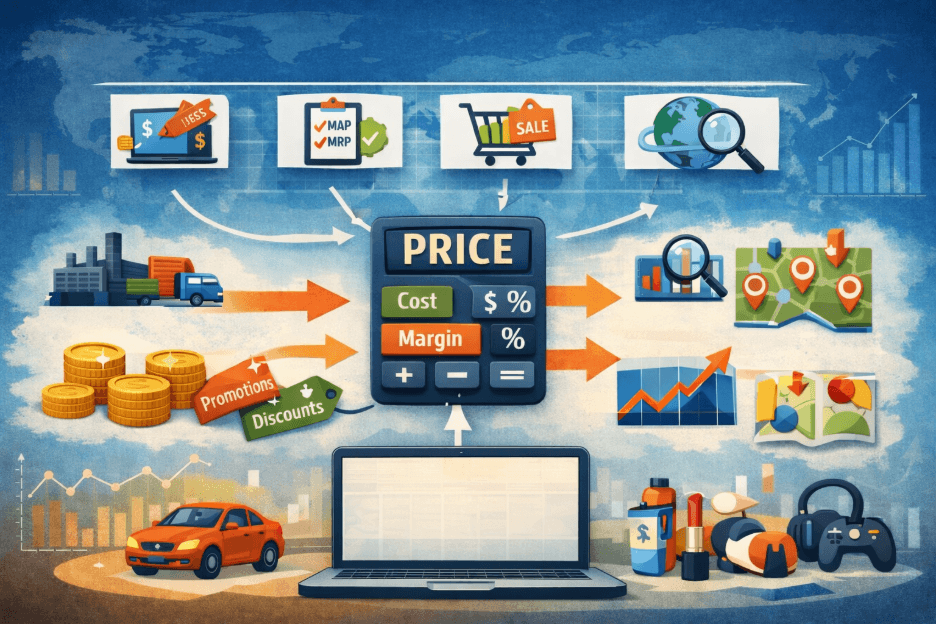

In [3]:
from IPython.display import  Image , display
display(Image(filename = "C:\python libraries/12.png"))

# 2. Project Summary 

“Pricing strategy is one of the most important factors affecting business performance. Different countries and markets behave differently based on economic conditions and customer demand. This project uses data analytics techniques to study pricing trends and generate business insights for smarter decision-making.”

Global businesses face challenges in setting optimal product prices because market conditions differ across countries.

This project focuses on analyzing pricing data using data analytics techniques to:
- Understand pricing trends
- Analyze sales and profit patterns
- Compare regional market performance
- Support smart business decision-making

The project uses Python, statistics, SQL concepts, Excel, and Power BI for analysis and visualization.

# 3. Problem Statement

1. Businesses struggle to optimize pricing strategies across global markets.
2. High prices may reduce customer demand.
3. Low prices may reduce profitability.
4. Market conditions vary based on GDP, population, and purchasing power.
5. Businesses require data-driven pricing insights for better decisions.


# 4. Import Libraries

In [1]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 5. Load Dataset

In [5]:
df=pd.read_csv("C:\python libraries\global_smart_pricing_.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\hp\AppData\Local\Temp\ipykernel_6868\745772560.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("C:\python libraries\global_smart_pricing_.csv")


In [6]:
print(df.head())
print(df.info())

   country     product     category  price_usd  units_sold  profit_usd  \
0   France  Headphones  Accessories     308.27         768    66376.72   
1    India       Phone  Electronics     652.83         375    58182.38   
2   Canada       Phone  Electronics     362.88         456    37304.33   
3  Germany      Tablet  Electronics     589.56         161     8074.67   
4   Brazil      Laptop  Electronics     138.09         467    10893.94   

   exchange_rate_to_usd  gdp_per_capita  population_millions  
0                  0.92           45000                   65  
1                 83.00            2500                 1400  
2                  1.35           52000                   38  
3                  0.92           52000                   83  
4                  5.10            9000                  213  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------          

# 6. Dataset Understanding

The dataset contains:
- Country information
- Product details
- Product category
- Product pricing
- Units sold
- Profit information
- Exchange rates
- GDP per capita
- Population statistics

## 7. Check Missing Values

In [7]:
print(df.isnull().sum())

country                 0
product                 0
category                0
price_usd               0
units_sold              0
profit_usd              0
exchange_rate_to_usd    0
gdp_per_capita          0
population_millions     0
dtype: int64


## 8. Handle Missing Values

In [8]:
# Numerical columns
num_cols = ['price_usd', 'units_sold', 'profit_usd',
            'exchange_rate_to_usd', 'gdp_per_capita', 'population_millions']

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical columns
cat_cols = ['country', 'product', 'category']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_6868\1406354328.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_6868\1406354328.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

# 9. Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

# 10. Outlier Detection Using Z-Score

In [10]:
z = stats.zscore(df['price_usd'])

df = df[(z < 3) & (z > -3)]

# 11. Feature Engineering

In [11]:
# Revenue column
df['revenue'] = df['price_usd'] * df['units_sold']

# Profit Margin
df['profit_margin'] = df['profit_usd'] / df['price_usd']

# Price Category
df['price_category'] = pd.cut(df['price_usd'],
                              bins=[0,50,100,200,500],
                              labels=['Low','Medium','High','Premium'])


# 12. Descriptive Statistics 

In [12]:
print(df.describe())

        price_usd  units_sold    profit_usd  exchange_rate_to_usd  \
count  1000.00000  1000.00000    1000.00000           1000.000000   
mean    518.54854   524.10900   46994.50805             23.408400   
std     275.65380   276.48525   46025.39420             47.036907   
min      50.30000    50.00000     783.12000              0.780000   
25%     278.35500   292.75000   14243.09250              0.920000   
50%     521.00500   518.00000   30819.45000              1.350000   
75%     746.06500   754.25000   64729.16250              5.100000   
max     999.04000  1000.00000  250087.12000            150.000000   

       gdp_per_capita  population_millions        revenue  profit_margin  
count     1000.000000           1000.00000    1000.000000    1000.000000  
mean     42812.000000            229.26200  270702.375180      91.433153  
std      19314.131917            393.49729  221348.997691      64.948329  
min       2500.000000             10.00000    7660.020000       2.731600  
25%

# 13. Correlation Analysis

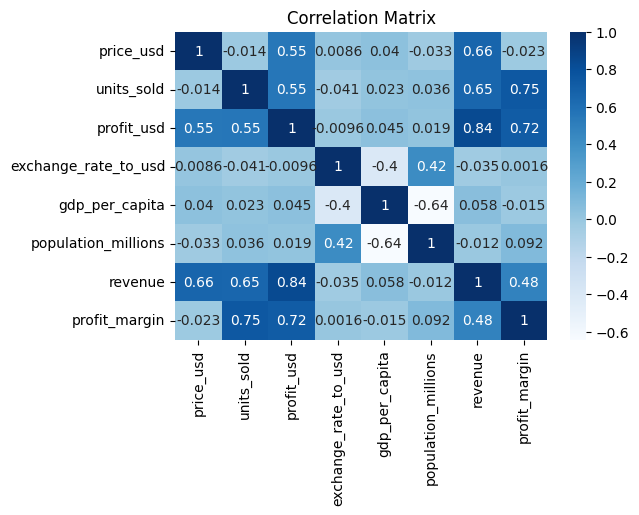

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

# 14. Country-wise Revenue Analysis

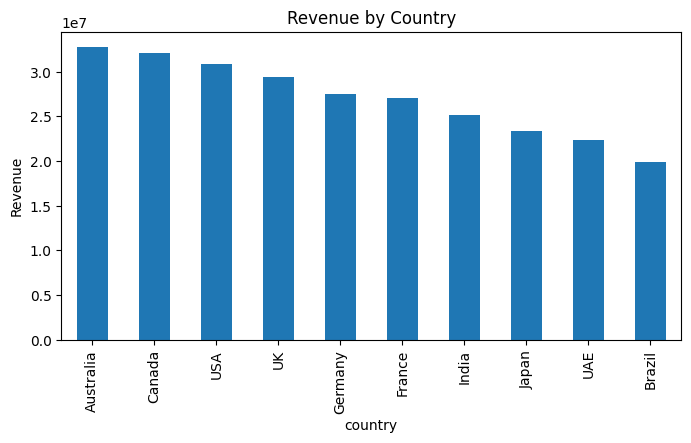

In [27]:
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

country_revenue.plot(kind='bar', figsize=(8,4))
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.show()

# 15. Product-wise Revenue Analysis

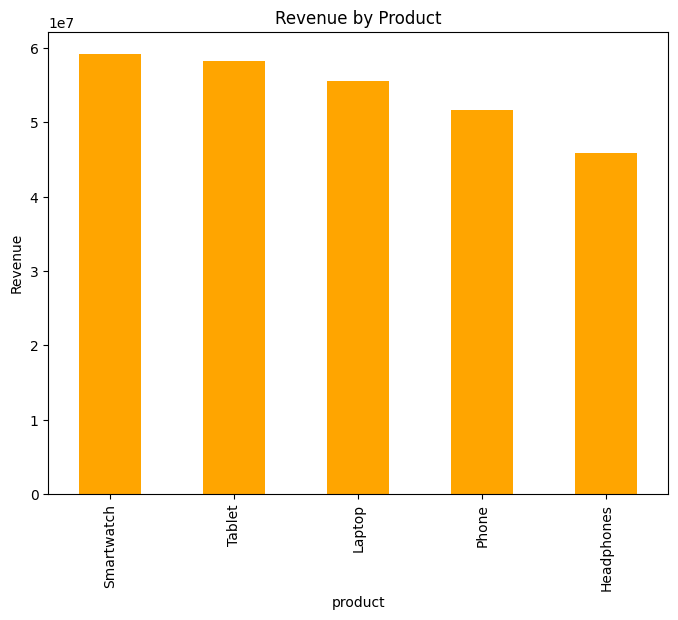

In [28]:
product_revenue = df.groupby('product')['revenue'].sum().sort_values(ascending=False)

product_revenue.plot(kind='bar', figsize=(8,6), color='orange')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

# 16. Price vs Units Sold

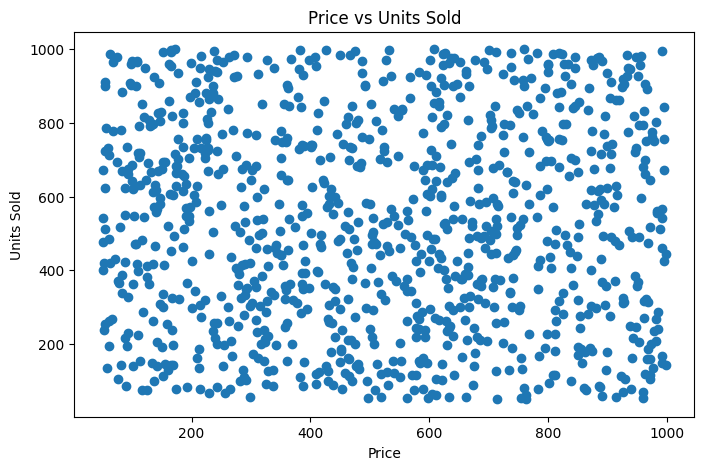

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df['price_usd'], df['units_sold'])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

# 17. GDP vs Revenue

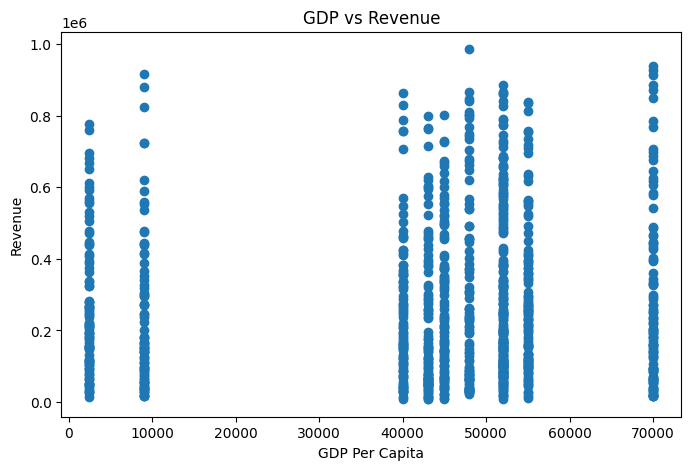

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['gdp_per_capita'], df['revenue'])
plt.xlabel("GDP Per Capita")
plt.ylabel("Revenue")
plt.title("GDP vs Revenue")
plt.show()


# 18. Population vs Units Sold

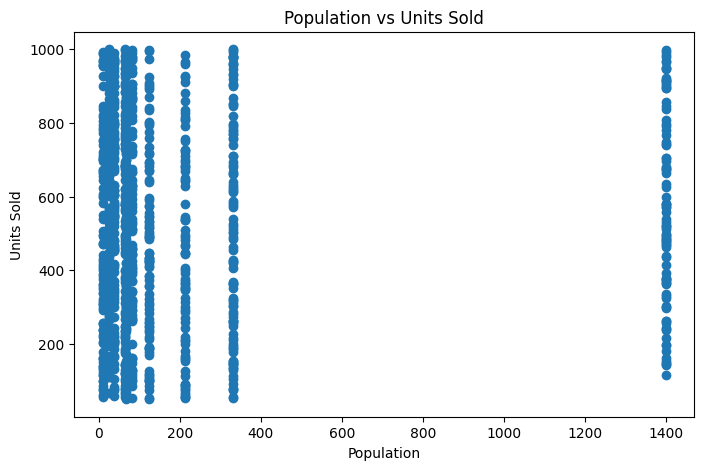

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df['population_millions'], df['units_sold'])
plt.xlabel("Population")
plt.ylabel("Units Sold")
plt.title("Population vs Units Sold")
plt.show()

# 19. Key Insights 

# Key Insights

1. Medium-priced products generate higher revenue.
2. Higher GDP countries show stronger purchasing power.
3. There is an inverse relationship between price and demand.
4. Certain products dominate revenue generation.
5. Economic indicators significantly influence pricing performance.

# 20. SQL Concepts Used


- SELECT
- WHERE
- GROUP BY
- HAVING
- SUM()
- AVG()
- COUNT()

# 21. Sample SQL Queries

SELECT country, SUM(revenue)
FROM sales
GROUP BY country;

SELECT product, AVG(price_usd)
FROM sales
GROUP BY product;

SELECT country, SUM(revenue)
FROM sales
GROUP BY country
HAVING SUM(revenue) > 100000;

# 22. Conclusion



This project demonstrates how data analytics can help businesses optimize global pricing strategies.

Using Python, statistics, SQL, Excel, and Power BI, meaningful insights were extracted regarding pricing, sales, revenue, and market performance.

The analysis supports better business decision-making and helps identify profitable market opportunities.


# 23. Future Scope 

- Machine Learning-based dynamic pricing
- Real-time dashboard integration
- Demand forecasting
- Customer segmentation analysis

In [ ]:
import os
print (os.getcwd)